<a href="https://colab.research.google.com/github/Nikolas-LS/Analise-de-dados-Tempo/blob/main/Tratamento_de_dados_Tempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando as Bibliotescas

In [ ]:
import pandas as pd
import seaborn as sns
import statistics as sts

Lendo o arquivo CSV

In [ ]:
dataset = pd.read_csv('tempo.csv', sep=';')

Visualizando os dados do arquivo

In [ ]:
dataset.head()

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85.0,85.0,FALSO,nao
1,sol,80.0,90.0,VERDADEIRO,nao
2,nublado,83.0,86.0,FALSO,sim
3,chuva,70.0,85.5,FALSO,sim
4,chuva,68.0,80.0,FALSO,sim


Visualizar se existem dados ausentes no "dataset"

In [ ]:
dataset.isnull().sum()

,0
Aparencia,0
Temperatura,0
Umidade,0
Vento,0
Jogar,0


---

**1º -** Agrupar a coluna "Aparencia" e analisar os dados

In [ ]:
agrupar_aparencia = dataset.groupby(['Aparencia']).size()
agrupar_aparencia

,0
Aparencia,
chuva,5
menos,1
nublado,3
sol,5


Visualizar os dados de "Aparencia" por meio de um gráfico

<Axes: xlabel='Aparencia'>

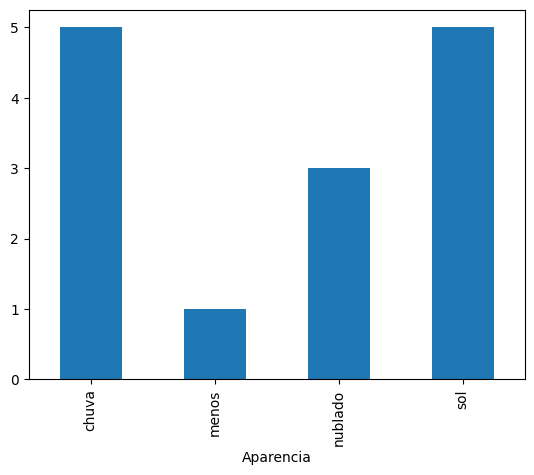

In [ ]:
agrupar_aparencia.plot.bar()

**CONCLUSÃO DA ANÁLISE:** A coluna "Aparencia" possui 1 registro que não corresponde com seus outros dados, é necessário fazer um tratamento nessa coluna.

In [ ]:
# Substituindo o dado incorreto pela MODA da coluna, o item escolhido foi "sol"
dataset.loc[dataset['Aparencia'] == 'menos', 'Aparencia'] = 'sol'

---

**2º -** Agrupar a coluna "Temperatura" e analisar os dados

In [ ]:
agrupar_temperatura = dataset.groupby(['Temperatura']).size()
agrupar_temperatura

,0
Temperatura,
64,1
65,1
68,1
69,1
70,1
71,1
72,1
75,2
80,1


Visualizar os dados de "Temperatura" por meio de um gráfico

<Axes: ylabel='Temperatura'>

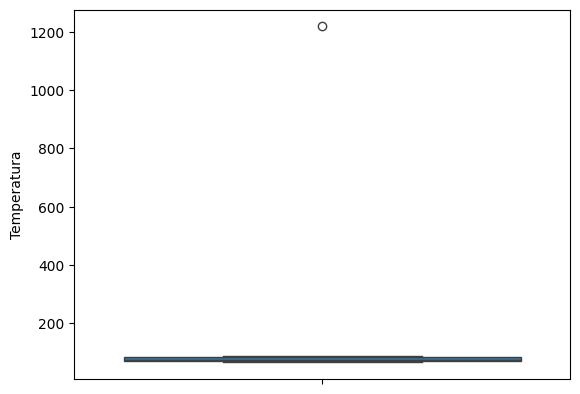

In [ ]:
sns.boxplot(dataset['Temperatura'])

**CONCLUSÃO DA ANÁLISE:** A coluna "Temperatura" possui 1 registro que não corresponde com seus outros dados, é necessário fazer um tratamento nessa coluna.

In [ ]:
# Calcular a mediana da coluna "Temperatura"
mediana = sts.median(dataset['Temperatura'])
mediana

73.5

In [ ]:
# Substituir o valor anomalo pela mediana da coluna "Temperatura"
dataset.loc[dataset['Temperatura'] == 1220, 'Temperatura'] = mediana

/tmp/ipykernel_1780/1541921378.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '73.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset.loc[dataset['Temperatura'] == 1220, 'Temperatura'] = mediana


---

**3º -** Agrupar a coluna "Umidade" e analisar os dados

In [ ]:
agrupar_umidade = dataset.groupby(['Umidade']).size()
agrupar_umidade

,0
Umidade,
65.0,1
70.0,3
75.0,1
80.0,1
85.0,1
85.5,1
86.0,1
90.0,2
91.0,1


Visualizar os dados de "Umidade" por meio de um gráfico



<Axes: xlabel='Umidade'>

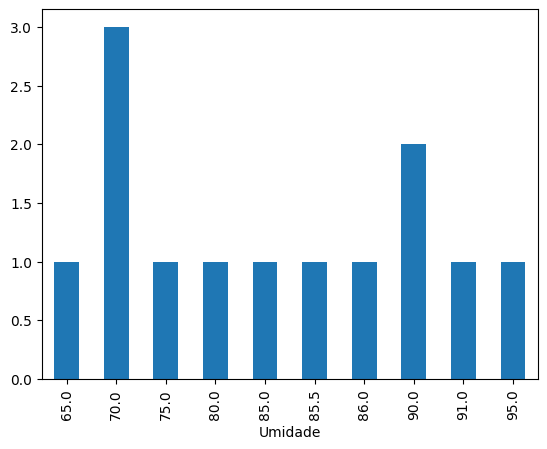

In [ ]:
agrupar_umidade.plot.bar()

**CONCLUSÃO DA ANÁLISE:** A coluna "Umidade" possui 1 registro que não corresponde com seus outros dados, e outro que está vazio. É necessário fazer um tratamento nessa coluna.

In [ ]:
# Calcular a mediana da coluna "Umidade"
mediana = sts.median(dataset['Umidade'])
mediana

85.5

In [ ]:
# Substituir o valor anomalo pela mediana da coluna "Umidade"
dataset.loc[dataset['Umidade'] == 200, 'Umidade'] = mediana

In [ ]:
# Corrigir o campo vazio pela mediana da coluna "Umidade"
dataset['Umidade'].fillna(mediana, inplace=True)

/tmp/ipykernel_1780/4274367953.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Umidade'].fillna(mediana, inplace=True)


---

**4º -** Agrupar a coluna "Vento" e analisar os dados

In [ ]:
agrupar_vento = dataset.groupby(['Vento']).size()
agrupar_vento

,0
Vento,
FALSO,8
VERDADEIRO,6


Visualizar os dados de "Umidade" por meio de um gráfico


<Axes: xlabel='Vento'>

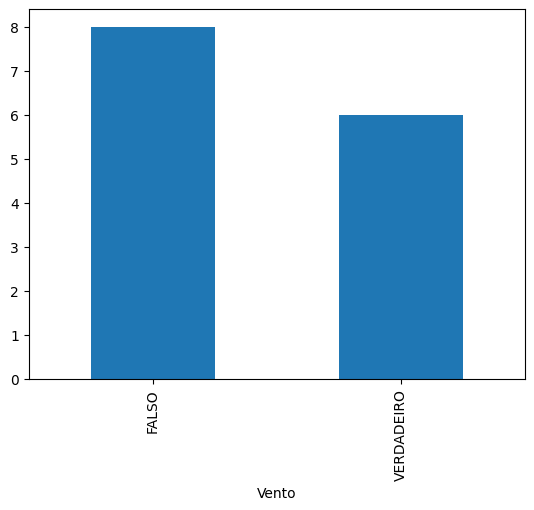

In [ ]:
agrupar_vento.plot.bar()

**CONCLUSÃO DA ANÁLISE:** A coluna "Vento" possui 1 registro que está vazio. É necessário fazer um tratamento nessa coluna.

In [ ]:
# Substituindo o dado incorreto pela MODA da coluna, o item escolhido foi "FALSO"
dataset['Vento'].fillna('FALSO', inplace=True)

/tmp/ipykernel_1780/785522868.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Vento'].fillna('FALSO', inplace=True)


In [ ]:
# Validar se temos valores nulos ainda
dataset['Vento'].isnull().sum()

np.int64(0)

---

**5º -** Agrupar a coluna "Jogar" e analisar os dados

In [ ]:
agrupar_jogar = dataset.groupby(['Jogar']).size()
agrupar_jogar

,0
Jogar,
nao,5
sim,9


<Axes: ylabel='Jogar'>

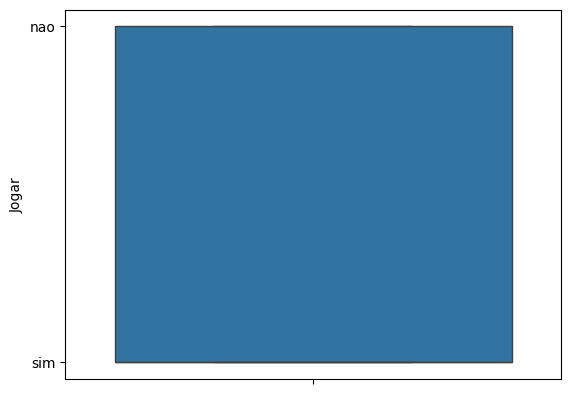

In [ ]:
sns.boxplot(dataset['Jogar'])

**CONCLUSÃO DA ANÁLISE:** A coluna "Jogar" está 100% correta. Não é necessário fazer um tratamento nessa coluna.

---

**CONCLUSÕES FINAIS!**

In [ ]:
display(dataset)

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85.0,85.0,FALSO,nao
1,sol,80.0,90.0,VERDADEIRO,nao
2,nublado,83.0,86.0,FALSO,sim
3,chuva,70.0,85.5,FALSO,sim
4,chuva,68.0,80.0,FALSO,sim
5,chuva,65.0,70.0,VERDADEIRO,nao
6,sol,64.0,65.0,VERDADEIRO,sim
7,sol,73.5,95.0,FALSO,nao
8,sol,69.0,70.0,FALSO,sim
9,chuva,75.0,85.5,FALSO,sim


In [ ]:
dataset.isnull().sum()

,0
Aparencia,0
Temperatura,0
Umidade,0
Vento,0
Jogar,0


**Fim da análise de dados do arquivo "tempo.csv"**

---